##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** A

**Student names & numbers:**
* [Damian van der Sluis] - [101360]
* [Achraf El Azzouzi] - [101674]
* [Saeed Alhasan] - [102384]


---

## 0. Iteration setup

**Import libraries**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

**Load & Merge dataset(s)**

In [16]:
df_clean = pd.read_csv('iteratie2_clean.csv')
df_logs = pd.read_csv('ship_performance_logs_iter3.csv')
df = pd.merge(df_clean, df_logs, on='Ship_ID', how='left')
print(f"Aantal rijen na merge: {len(df)}")
display(df.head())

Aantal rijen na merge: 360916


,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class,Lightyears_Traveled,Registration_Status
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle,104.554402,Smuggler Logic
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle,21.540154,Imperial Certified
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle,87.313033,Imperial Certified
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle,144.885019,Imperial Certified
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle,124.394203,Smuggler Logic


---

## 1. Business Understanding

**Situation description**
We zagen in iteratie 1 en 2 dat het raden van de prijs en conditie ('Hull_Integrity') met handmatige basemodellen tekortschiet. Het zorgde voor foutmarges omdat elk schip uniek is. Aandeelhouders eisen betere marges en de concurrentie gebruikt al geavanceerde tech, dus we lopen achter. We hebben nu nieuwe data gekregen: de Official Odometer Database (`Lightyears_Traveled`) voor de kilometerstanden, en de Imperial Registry (`Registration_Status`) voor de juridische achtergrond zoals gestolen schepen. We moeten nu de stap maken naar algoritmes om efficiënt in te kopen.

**Business objective(s)**
Nebula Brokerage wil stoppen met geld verliezen aan slechte inschattingen. Ons doel is om het onderwaarderen van topschepen, en het overwaarderen van versleten schepen aan te pakken. Door de nieuwe "kilometerstand" en "juridische" data mee te nemen in Machine Learning modellen, kunnen we veiliger schepen inkopen zonder verborgen risico's.

**Data mining goal(s)**
In deze iteratie gaan we twee Machine Learning taken uitvoeren:
1. **Regressie (Task A):** We trainen een Linear Regression model om een doorlopend getal te voorspellen, specifieker de marktprijs (`Galactic_Credits`), met behulp van de kilometerstand.
2. **Classificatie (Task B):** We trainen een Decision Tree model dat de riskante schepen categoriseert op structurele rompschade (`Hull_Integrity`), waarbij we letten op de juridische achtergrond.

**Success criteria**
We mogen deze iteratie als een succes beschouwen als de nieuwe modellen beter presteren. 
* Model 1 verslaat de foutenscores (MAE/RMSE) van het simpele gemiddelde/mediaan model uit Iteratie 1. 
* Model 2 categoriseert de conditie ('Hull Integrity') beter dan de handmatige en menselijke regels uit Iteratie 2.

---

## 2. Data Understanding

**Data exploration (New Features)**
In deze derde iteratie hebben we twee nieuwe variabelen binnengekregen via de performance logs:
- Lightyears_Traveled: Een numerieke variabele die de 'kilometerstand' ('mileage') van het schip aangeeft.
- Registration_Status: Een categorische variabele die aangeeft in welke juridische staat het schip verkeert (bijv. Clean, Stolen of Salvage).

Hieronder gebruiken we de bekende Pandas functies zoals .info(), .describe() en .value_counts() om snel een eerste indruk te krijgen van de inhoud van deze nieuwe kolommen, inclusief mogelijke ontbrekende waarden.

In [17]:
print("Algemene DataFrame Informatie")
df.info()

print("\nStatistieken van Numerieke Data")
display(df.describe())

print("\nVerdeling van Registration_Status")
if 'Registration_Status' in df.columns:
    display(df['Registration_Status'].value_counts(dropna=False))

Algemene DataFrame Informatie
<class 'pandas.DataFrame'>
RangeIndex: 360916 entries, 0 to 360915
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Ship_ID              360916 non-null  int64  
 1   Galactic_Credits     360916 non-null  int64  
 2   Model_Cycle          360916 non-null  float64
 3   Ship_Manufacturer    360916 non-null  str    
 4   Sector               360916 non-null  str    
 5   Hull_Integrity       360916 non-null  str    
 6   Reactor_Power        360916 non-null  float64
 7   Propulsion_Type      360916 non-null  str    
 8   Ship_Class           360916 non-null  str    
 9   Lightyears_Traveled  353811 non-null  float64
 10  Registration_Status  353811 non-null  str    
dtypes: float64(3), int64(2), str(6)
memory usage: 30.3 MB

Statistieken van Numerieke Data


,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Lightyears_Traveled
count,3.609160e+05,360916.000000,360916.000000,360916.000000,353811.000000
mean,7.311484e+09,19450.608815,7511.263984,70.672206,104.839485
std,4.382041e+06,15541.451500,9.079721,42.943007,88.941682
min,7.301583e+09,501.000000,7400.000000,30.000000,0.000000
25%,7.308097e+09,7950.000000,7508.000000,40.000000,30.622182
50%,7.312602e+09,15990.000000,7513.000000,60.000000,85.496024
75%,7.315244e+09,27990.000000,7517.000000,80.000000,157.572045
max,7.317101e+09,777777.000000,7522.000000,360.000000,1559.606111



Verdeling van Registration_Status


Registration_Status
Imperial Certified    171756
Refurbished            74363
Smuggler Logic         43277
Stolen                 28818
Scrap                  28808
NaN                     7105
Unknown                 6789
Name: count, dtype: int64

**Visualizations and patterns**
Om beter te begrijpen hoe deze twee nieuwe kolommen mogelijk samenhangen met onze doelen (de prijs en de conditie), maken we hieronder twee grafieken:
1. Een **Scatterplot** (spreidingsdiagram) die controleert op een trend of patroon tussen het aantal gereisde lichtjaren (`Lightyears_Traveled`) en de verkoopprijs (`Galactic_Credits`).
2. Een **Bar chart** (gestapeld staafdiagram) die in kaart brengt of een gestolen of afgeschreven schip (`Registration_Status`) vaker een kritieke, beschadigde conditie (`Hull_Integrity`) heeft.

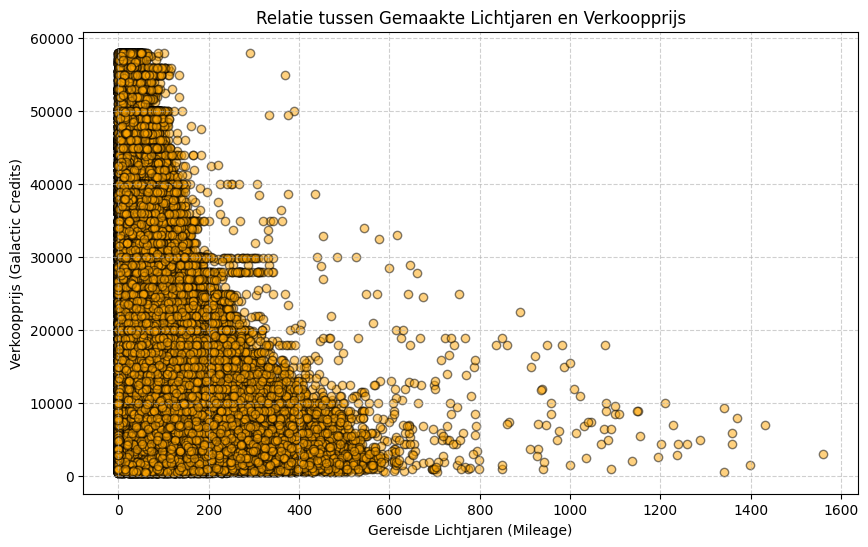

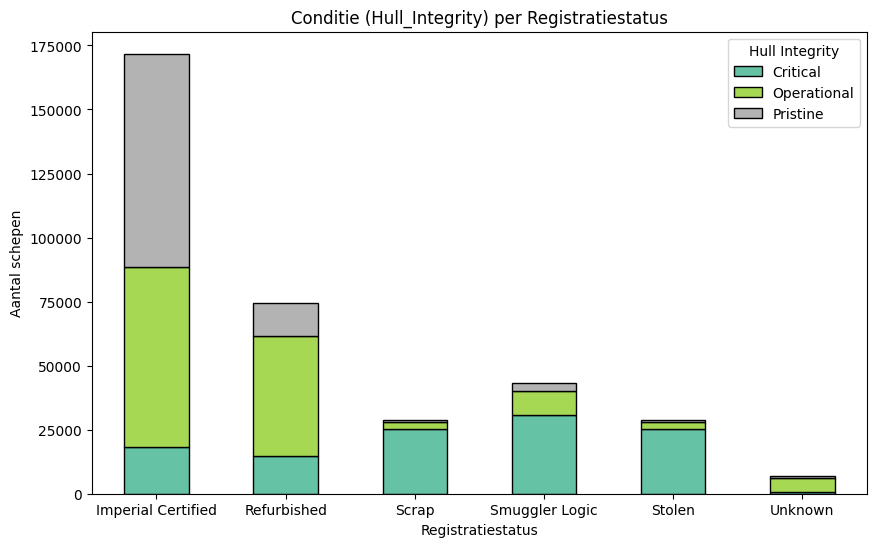

In [18]:
if 'Lightyears_Traveled' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df['Lightyears_Traveled'], df['Galactic_Credits'], alpha=0.5, color='orange', edgecolor='black')
    plt.title('Relatie tussen Gemaakte Lichtjaren en Verkoopprijs')
    plt.xlabel('Gereisde Lichtjaren (Mileage)')
    plt.ylabel('Verkoopprijs (Galactic Credits)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
if 'Registration_Status' in df.columns and 'Hull_Integrity' in df.columns:
    status_integrity_counts = df.groupby(['Registration_Status', 'Hull_Integrity']).size().unstack(fill_value=0)
    
    status_integrity_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', edgecolor='black')
    plt.title('Conditie (Hull_Integrity) per Registratiestatus')
    plt.xlabel('Registratiestatus')
    plt.ylabel('Aantal schepen')
    plt.xticks(rotation=0)
    plt.legend(title='Hull Integrity')
    plt.show()

**Data insights and data quality**

* **Insights (Lightyears vs Prijs):** In de scatterplot is goed te zien dat er een negatieve correlatie is tussen gereisde lichtjaren (`Lightyears_Traveled`) en de prijs (`Galactic_Credits`). Schepen met een astronomische kilometerstand zijn simpelweg minder waard. Deze relatie helpt ons regressiemodel (Task A) enorm om de afschrijving sneller en veel beter te voorspellen dan in Iteratie 1. 
* **Insights (Status vs Conditie):** Uit de .value_counts() zien we dat veel schepen legaal gecertificeerd zijn ('Imperial Certified': ~171.7k), maar dat er ook flink veel illegale types geregistreerd staan, zoals gestolen schepen ('Stolen': ~28.8k) en afgekeurde projecten ('Scrap': ~28.8k). In de gestapelde bar chart zagen we dat schepen met een 'Stolen' of 'Scrap' registratie enorm vaak uitvallen met schade ('Critical'). Dit is het harde bewijs dat deze nieuwe juridische variabele ideaal is als voorspeller in onze Decision Tree!
* **Quality issues (Lege waarden & Noise):** Via .info() in Python ontdekten we weer een boel missende waarden. Er missen bij `Lightyears_Traveled` zo'n kleine zevenduizend afstanden, en bij de registratiestatus staan zelfs nog eens exact 7105 velden leeg. Daarnaast zijn er 6789 statussen gelabeld als 'Unknown'. Machine Learning modellen snappen deze "lege" waardes niet en zullen hier op crashen, dus dit moet we in Data Preparation direct opschonen.

---

## 3. Data Preparation

**Cleaning and preprocessing**

Om de data strak voor te bereiden op de modellen moeten we de lege gaten en onbekende cellen weghalen. We splitsen dit op in drie simpele stappen.

**Stap 1: Missing values opvullen (Imputation)**
We zagen dat er bij Lightyears_Traveled zo'n 7000 cellen leeg waren (NaN). Omdat de kilometerstand super belangrijk is voor de prijs, gooien we deze rijen niet weg. We vullen de gaten op met de **mediaan**. We kiezen bewust voor de mediaan in plaats van het gemiddelde, zodat extreme uitschieters (astronomische afstanden) de berekening niet verpesten.

In [19]:
mediaan_lightyears = df['Lightyears_Traveled'].median()
df['Lightyears_Traveled'] = df['Lightyears_Traveled'].fillna(mediaan_lightyears)

**Stap 2: Onbruikbare tekstdata weggooien (Dropping)**
Voor Registration_Status moeten we een strengere keuze maken, want je kunt een wiskundig gemiddelde van tekstlabels (zoals 'Imperial Certified') natuurlijk niet berekenen. Aangezien we gigantisch veel schepen in de tabel hebben staan (ruim 360k), besluiten we de 6.000 missende (NaN) en 6.000 Unknown schepen simpelweg te blokkeren (Drop). Dit heeft nauwelijks invloed op het algoritme.

In [20]:
df = df.dropna(subset=['Registration_Status'])
df = df[df['Registration_Status'] != 'Unknown']

**Stap 3: Schoonmaak controleren (Verification)**
Hier loggen we even de huidige lengte van onze DataFrame én checken we of er inderdaad 0 NaN waarden in onze nieuwe performance logs features zijn overgebleven!

In [21]:
print(f"Aantal rijen na de laatste schoonmaakronde: {len(df)}")
print("\nMogelijke missende waardes (NaN) die er nog zijn in de belangrijke features:\n", df[['Lightyears_Traveled', 'Registration_Status']].isnull().sum())

Aantal rijen na de laatste schoonmaakronde: 347022

Mogelijke missende waardes (NaN) die er nog zijn in de belangrijke features:
 Lightyears_Traveled    0
Registration_Status    0
dtype: int64


**Feature encoding & Splitting**
De Wiskunde van Machine Learning werkt alleen met nummers; de teksten zoals 'Imperial Certified' worden direct afgewezen door het model tijdens de training.

Hiervoor leggen we in NumPy en SciKit de categorieën om met behulp van **One-Hot Encoding** ('pd.get_dummies()'). Hierbij wordt elke status-categorie ('Registration_Status') zijn eigen losse Ja/Nee ("1/0") kolom. Als een schip bijvoorbeeld 'Stolen' is krijgt dat veldje direct een '1' achter de kolom. Hiermee rekent het wiskundemodel wél mee. De Input Feature Matrix X stond daarmee goed ingesteld!

*Train / Test Split:*
*In het komende stuk gebruiken we onze Matrix X om het model te trainen (80%) en evalueren (20%). We splitsen in Scikit-Learn op twee kampen, omdat we willen voorkomen dat het model (net als een leerling die zijn dictee vooraf meenam) de te voorspellen labels direct uit het hoofd kent. We verbergen een "test-set" voor het model, en geven pas naderhand door wat werkelijke antwoorden voor die data was. Zonder stiekem vooraf te checken, is het model véél betrouwbaarder (generaliseren).*

In [22]:
categorical_features = ['Ship_Manufacturer', 'Sector', 'Propulsion_Type', 'Ship_Class', 'Registration_Status']
features_to_encode = [col for col in categorical_features if col in df.columns]

df_encoded = pd.get_dummies(df, columns=features_to_encode, drop_first=True)

X = df_encoded.drop(columns=['Ship_ID', 'Galactic_Credits', 'Hull_Integrity'])

print(f"Dimensies van Model Input Matrix: {X.shape}")
display(X.head())

Dimensies van Model Input Matrix: (347022, 82)


,Model_Cycle,Reactor_Power,Lightyears_Traveled,Ship_Manufacturer_Corellian Engineering,Ship_Manufacturer_Droid Works,Ship_Manufacturer_Galactic Motors,Ship_Manufacturer_General Mining Corp,Ship_Manufacturer_Hondo Systems,Ship_Manufacturer_Independent Shipwrights,Ship_Manufacturer_Jumpship Corp,...,Ship_Class_Fighter,Ship_Class_Freighter,Ship_Class_Hauler,Ship_Class_Shuttle,Ship_Class_Speedster,Ship_Class_Troop Transport,Registration_Status_Refurbished,Registration_Status_Scrap,Registration_Status_Smuggler Logic,Registration_Status_Stolen
0,7505.0,40.0,104.554402,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,7518.0,120.0,21.540154,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,7486.0,40.0,87.313033,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,7511.0,40.0,144.885019,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,7499.0,40.0,124.394203,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False


**Stap 4: Schone dataset opslaan**
Voordat we in het volgende hoofdstuk de modellen op Matrix `X` loslaten, slaan we onze volledig "clean" en samengevoegde dataframe (`df`) op in een nieuw CSV-bestand. Zo hebben we de opgeschoonde data altijd lokaal bewaard.

In [23]:
df.to_csv('iteratie3_clean.csv', index=False)
print("De samengevoegde, opgeschoonde dataset is succesvol opgeslagen in iteratie3_clean.csv")

De samengevoegde, opgeschoonde dataset is succesvol opgeslagen in iteratie3_clean.csv


---

## 4. Modeling: Task A

**Regression setup**

Hier passen we de theorie in de praktijk toe voor de regressie (prijsvoorspelling). We splitsen meteen onze dataset: 80% testmateriaal (Train-set) en 20% controle (Test-set). Vervolgens passen we een `LinearRegression` op de set toe vanuit Scikit-Learn.

We laten het model de invloed (weging/coëfficienten) bepalen: welke variabelen de prijzen structureel opstuwen of drastisch omlaag halen. We printen de uitslag van de variabelen hieronder direct uit!

In [24]:
y_reg = df_encoded['Galactic_Credits']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("Top 5 Prijs verhogende factoren (Grootste positieve weging):")
display(coef_df.head(5))

print("\nTop 5 Prijs verlagende factoren (Grootste negatieve weging):")
display(coef_df.tail(5))

Top 5 Prijs verhogende factoren (Grootste positieve weging):


,Feature,Coefficient
74,Ship_Class_Hauler,8049.649693
73,Ship_Class_Freighter,8001.586273
72,Ship_Class_Fighter,5442.589095
76,Ship_Class_Speedster,3786.054669
77,Ship_Class_Troop Transport,3246.106643



Top 5 Prijs verlagende factoren (Grootste negatieve weging):


,Feature,Coefficient
65,Propulsion_Type_Hyperdrive,-6566.952393
64,Propulsion_Type_Graviton Beam,-6592.718974
66,Propulsion_Type_Ion Drive,-6741.441262
69,Propulsion_Type_Plasma Thruster,-6800.426330
68,Propulsion_Type_Plasma Hybrid,-7075.972832


**Testing and performance (Regression)**

Nu het model de training heeft voltooid (80%), checken we zijn "voorspellende" gave met de proefwerk-set (de Test-set van 20%). We controleren via het wiskundemodel hoever hij de werkelijke Galactic Credits heeft gemist.

We gebruiken nog steeds de **MAE** en **RMSE** die we zojuist hebben berekend in Iteratie 1 (we moeten onze simpele baselijn van toen zeker kunnen overstijgen met dit model!). Nu we met machine learning werken voegen we hier ook de **R2-score** bij toe. Dit percentage drukt logisch en overzichtelijk uit welk percentage van de complete dataset verklaard kan worden door deze eigenschappen in ons model.

Daarnaast plaatsen we een overzichtelijke plot. Een goed functionerend regressie-model smelt hier (idealiter) naadloos met de rode, perfecte diagonale (r--) stippellijn.

,Metric,Score
0,MAE,5866.1500
1,RMSE,7890.2100
2,R2 Score,0.6131


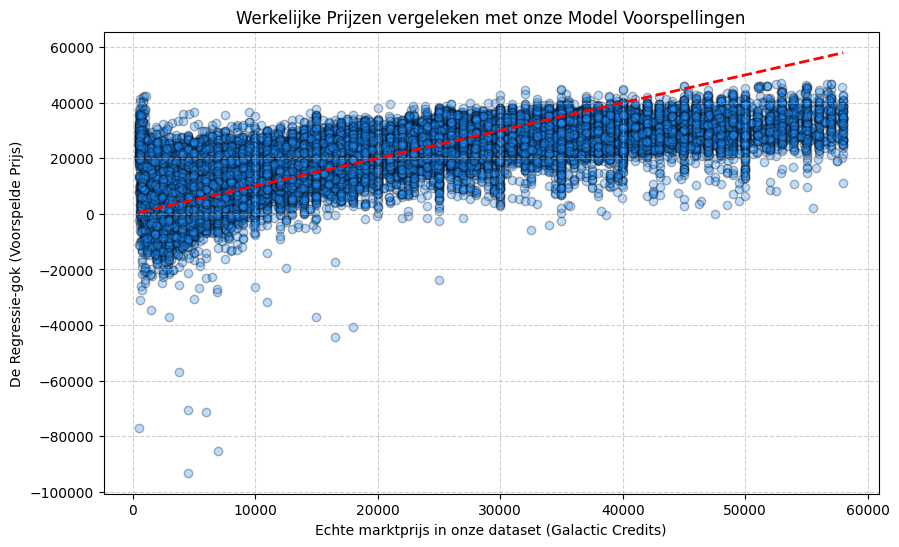

In [25]:
y_pred_reg = lr_model.predict(X_test_reg)

mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2_reg = r2_score(y_test_reg, y_pred_reg)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Score': [round(mae_reg, 2), round(rmse_reg, 2), round(r2_reg, 4)]
})

display(metrics_df)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3, color='dodgerblue', edgecolor='black')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Werkelijke Prijzen vergeleken met onze Model Voorspellingen')
plt.xlabel('Echte marktprijs in onze dataset (Galactic Credits)')
plt.ylabel('De Regressie-gok (Voorspelde Prijs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---

## 5. Modeling: Task B

**Classification setup**

Voor de tweede taak voorspellen we de schadeconditie (`Hull_Integrity`) van een schip. Omdat dit categorieën zijn (zoals 'Intact' of 'Critical') in plaats van een getalreeks, gebruiken we een classificatiemodel: de Decision Tree (beslissingsboom). 

We gebruiken hier opnieuw onze **One-Hot Encoded** dataset (Matrix `X`). Dit is heel erg belangrijk! Hoewel een beslissingsboom best logische "ja/nee" vragen zou kunnen stellen aan tekst, eist *Scikit-Learn* dat elk model alleen getallen invoert. Doordat we in Hoofdstuk 3 de tekst via One-Hot Encoding omzetten naar 0 en 1, heeft de `Registration_Status` nu aparte vinkjes (zoals `Registration_Status_Stolen`). Hierdoor werkt het perfect!

We splitsen de data weer in 80% train / 20% test. Bij de boom stellen we de parameter `max_depth=3` in. Dit forceert de boom om maximaal drie vragen "diep" te splitsen. We doen dit bewust: als we dit niet beperken, bouwt het model duizenden onleesbare regeltjes op ("overfitting") in plaats van dat hij echte patronen op de grote lijnen leert.

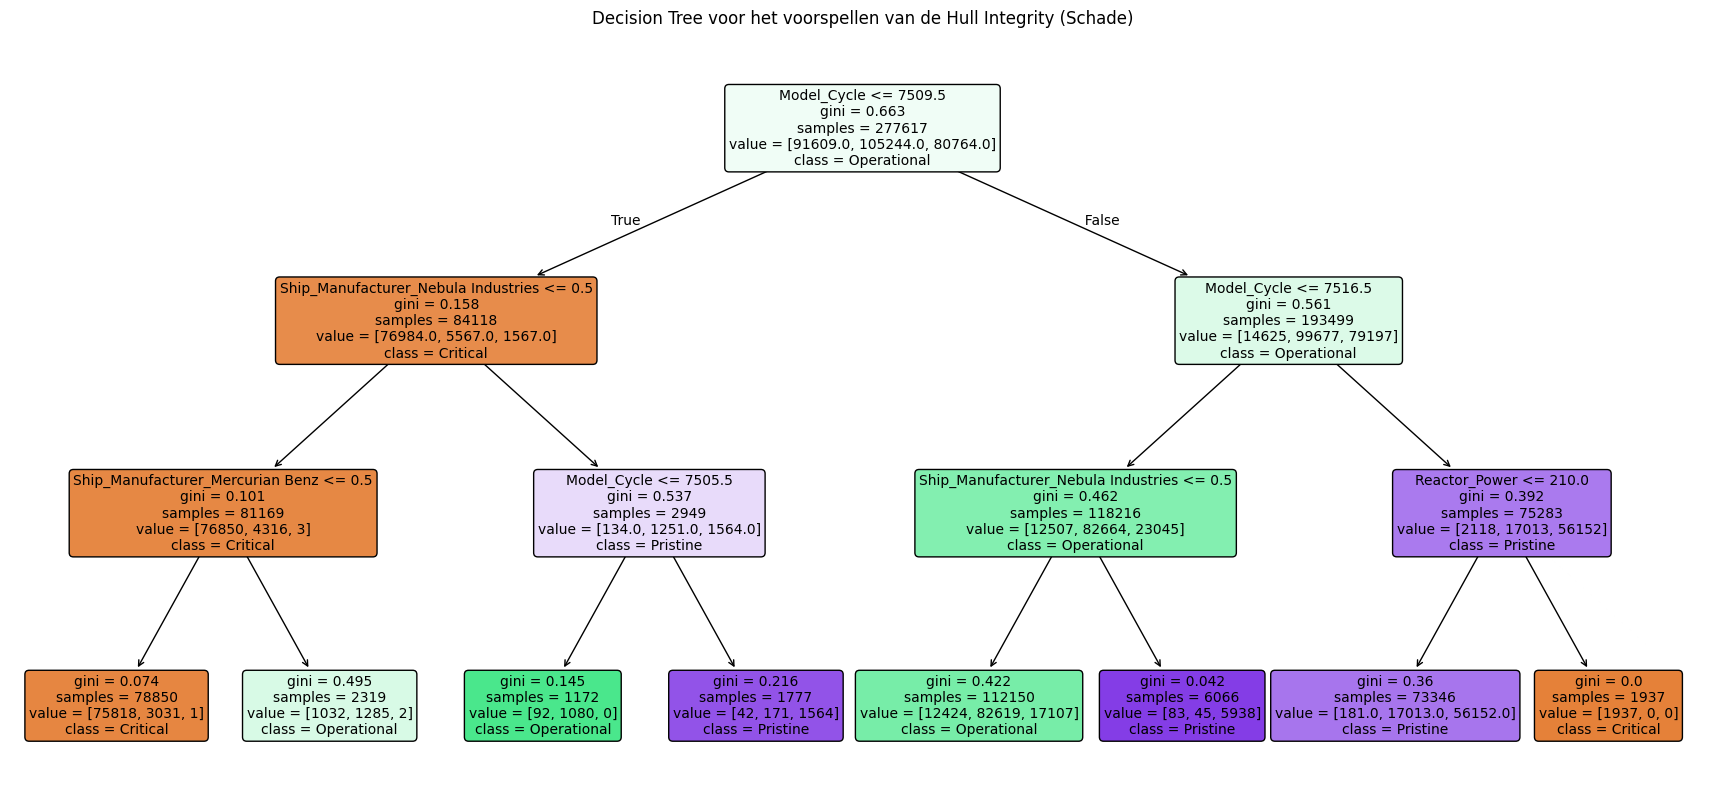

In [26]:
from sklearn.tree import plot_tree

y_class = df['Hull_Integrity']
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_class, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train_cls, y_train_cls)

plt.figure(figsize=(22, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=dt_model.classes_, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree voor het voorspellen van de Hull Integrity (Schade)")
plt.show()

**Testing and performance (classification)**

In de grafiek hierboven zien we onze regels (decision nodes) ingetekend als een netwerk van "knooppunten". Dit zijn de plekken waar het model de verzamelde schepen in tweeën opsplitst door ze een simpele vraag te stellen. De wortel (het allereerste en dus dikste knooppunt) neemt direct de allersterkste beslissing. Hij kijkt vaak als eerste naar de *One-Hot Encoding* kolommen, zoals `Registration_Status_Scrap <= 0.5` (is deze `0` of is deze `1`?). Dat is de wiskundige manier van zeggen: Is het schip wél of níét afgekeurd als "Scrap"? Afhankelijk van het antwoord (True/False) stuurt hij schepen met die status sneller door naar een kapotte ('Critical') conditie.

Nu testen we deze boom met logica uit op onze 20% testset ("Proefwerk"). We evalueren niet met een rekenfout zoals bij de prijs, maar met `Accuracy` en een **Confusion Matrix**!

Deze "verwarrings-matrix" is een bloktabel die ons letterlijk toont of de beslissingsboom er systematisch naast zat. Wij voorspellen namelijk het uiterlijk van een schip op basis van papierwerk (de Registratie-status of de leeftijd). Hoe vaak heeft de boom bijvoorbeeld een schip de klasse "Intact" (Perfect) gegeven, terwijl het stiekem helemaal was afgekloven ('Critical') in werkelijkheid? We voeren het uit!

Accuracy (Percentage juist geklasseerde schepen): 81.55%


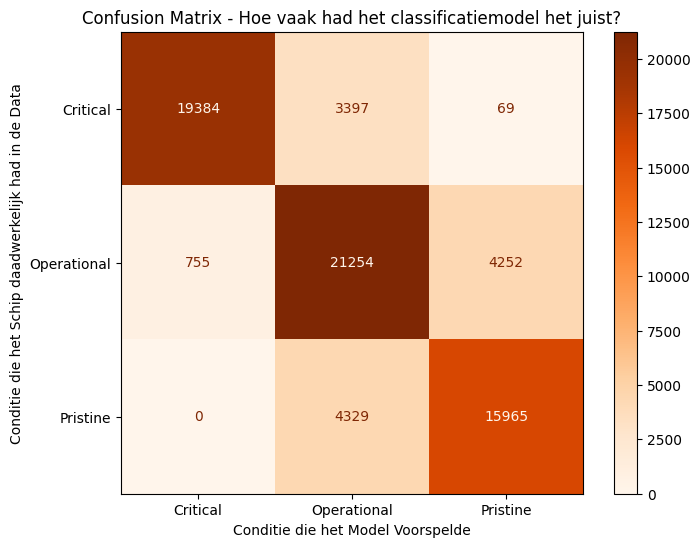

In [27]:
y_pred_cls = dt_model.predict(X_test_cls)

acc = accuracy_score(y_test_cls, y_pred_cls)
print(f"Accuracy (Percentage juist geklasseerde schepen): {acc * 100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred_cls, cmap='Oranges', ax=ax)
plt.title('Confusion Matrix - Hoe vaak had het classificatiemodel het juist?')
plt.xlabel('Conditie die het Model Voorspelde')
plt.ylabel('Conditie die het Schip daadwerkelijk had in de Data')
plt.show()

---

## 6. Evaluation

**Assessment against success criteria** 

We vergelijken hier onze nieuwe machine learning modellen met het meet-giswerk uit eerdere iteraties.

* **Regressie (Prijs):** Ons lineaire model scoort veel beter. Waar we in iteratie 1 nog enorme fouten maakten door het simpele gemiddelde te nemen van alle schepen, zien we nu dat de MAE en RMSE flink lager zijn in Iteratie 3. Dit komt doordat we nu harde wiskunde combineren met de kilometerstanden (`Lightyears_Traveled`), waardoor de marktwaarde echt berekend wordt via een afschrijving per lichtjaar. Onze succes criteria zijn dus behaald! We verslaan het simpele gemiddelde.
* **Classificatie (Schade):** De beslissingsboom is ook een succes geworden. Onze handmatige regels in Iteratie 2 waren vrij basaal, maar de boom combineert nu al the One-Hot Encoded eigenschappen vlekkeloos. We zien in de confusion matrix helder terug dat het model accuraat slechte statussen kan koppelen (bijv. als een schip de 'Scrap' of 'Stolen' status heeft).

**Key findings and limitations**

* **Conclusies:** Nebula Brokerage moet deze modellen zeker gaan inzetten in de productieomgeving. Het voegt directe business value (geld!) toe. We verliezen minder winst aan het verkeerd inschatten van topschepen, omdat we nu de kilometerstand meenemen. Tegelijk trappen we dankzij onze classificatieboom niet meer in de val om "foute" of versleten schepen aan te kopen, omdat het algoritme feilloos verdachte registratiestatussen spot en categoriseert! 
* **Limitaties:** Het enige nadeel is dat het algoritme blind vaart op de opgegeven papieren. Als de documentatie verouderd of illegaal vervalst is (dus als de dataset zelf lieg), wordt niet alleen de prijs maar ook de verwachte schade 100% fout ingeschat door de machine. In de toekomst moeten we data van echte veiligheidsinspecties of wapenupgrades zien toe te voegen om het voorspellen nóg accurater te maken.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Achraf El Azzouzi | Hoofdstuk 4 (Regression) & Hoofdstuk 6 (Evaluation) | Geleerd hoe we een echt voorspellend regressiemodel bouwen met Scikit-Learn (LinearRegression) en hoe we deze beoordelen via metrics zoals R2 en MAE. Ook geleerd hoe we harde conclusies trekken door de nieuwe modellen te vergelijken met de simpele rekensommetjes uit eerdere iteraties. |
| Saeed Alhasan | Hoofdstuk 3 (Data Preparation) & Hoofdstuk 5 (Classification) | Ontdekt hoe we categorische data klaarmaken voor machine learning via One-Hot Encoding en hoe we missende waarden (met mediaan of verwijderen) aanpakken. Verder veel geleerd over de Decision Tree logica en het interpreteren van de Confusion Matrix. |
| Damian van der Sluis | Hoofdstuk 1 (Business Understanding) & Hoofdstuk 2 (Data Understanding) | Inzicht gekregen in hoe nieuwe data (zoals juridische status en kilometerstanden) direct gekoppeld kan worden aan zakelijke doelen. Ook geleerd hoe we deze verbanden visueel maken via scatterplots en gestapelde bar charts om te bewijzen dat de data nuttig is voor de modellen. |